In [ ]:


import feedparser

# L'URL correcte pointe vers le flux RSS (XML) de l'ANSSI
url = "https://www.cert.ssi.gouv.fr/avis/feed/"
rss_feed = feedparser.parse(url)

# Parcourir chaque entrée du flux
for entry in rss_feed.entries:
    print("Titre :", entry.title)
    print("Description :", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)
    
    # Récupération de l'ID unique si disponible
    if 'id' in entry:
        print("ID :", entry.id)
        
    print("-" * 60)

Pour voir tout ce qu'il y a comme flux scrapable

In [ ]:
import requests
import re
url = "https://www.cert.ssi.gouv.fr/alerte/CERTFR-2024-ALE-001/json/"
response = requests.get(url)
data = response.json()
#Extraction des CVE reference dans la clé cves du dict data
ref_cves=list(data["cves"])
#attention il s’agit d’une liste des dictionnaires avec name et url comme clés
print( "CVE référencés ", ref_cves)
# Extraction des CVE avec une regex
cve_pattern = r"CVE-\d{4}-\d{4,7}"
cve_list = list(set(re.findall(cve_pattern, str(data))))
print("CVE trouvés :", cve_list)


Exemple de connexion à l'API CVE :

In [ ]:
import requests
cve_id = "CVE-2023-24488"
url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
response = requests.get(url)
data = response.json()

# Extraire la description
description = data["containers"]["cna"]["descriptions"][0]["value"]

# Extraire le score CVSS
#ATTENTION tous les CVE ne contiennent pas nécessairement ce champ, gérez l’exception,
#ou peut etre au lieu de cvssV3_0 c’est cvssV3_1 ou autre clé
cvss_score =data["containers"]["cna"]["metrics"][0]["cvssV3_1"]["baseScore"]

cwe = "Non disponible"
cwe_desc="Non disponible"
problemtype = data["containers"]["cna"].get("problemTypes", {})
if problemtype and "descriptions" in problemtype[0]:
    cwe = problemtype[0]["descriptions"][0].get("cweId", "Non disponible")
    cwe_desc=problemtype[0]["descriptions"][0].get("description", "Non disponible")

# Extraire les produits affectés
affected = data["containers"]["cna"]["affected"]
for product in affected:
    vendor = product["vendor"]
    product_name = product["product"]
    versions = [v["version"] for v in product["versions"] if v["status"] == "affected"]
    print(f"Éditeur : {vendor}, Produit : {product_name}, Versions : {', '.join(versions)}")
    
# Afficher les résultats
print(f"CVE : {cve_id}")
print(f"Description : {description}")
print(f"Score CVSS : {cvss_score}")
print(f"Type CWE : {cwe}")
print(f"CWE Description : {cwe_desc}")


Exemple de connexion à l’API EPSS:

In [ ]:
import requests
# URL de l'API EPSS pour récupérer la probabilité d'exploitation
cve_id = "CVE-2023-46805"
url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
# Requête GET pour récupérer les données JSON
response = requests.get(url)
data = response.json()
# Extraire le score EPSS
epss_data = data.get("data", [])
if epss_data:
    epss_score = epss_data[0]["epss"]
    print(f"CVE : {cve_id}")
    print(f"Score EPSS : {epss_score}")
else:
    print(f"Aucun score EPSS trouvé pour {cve_id}")


avec description:

In [ ]:
import feedparser
import requests
import re
import pandas as pd
import time
import csv

# --- PARAMÈTRES DE LIMITATION ---
MAX_BULLETINS = 20         
MAX_CVE_PER_BULLETIN = 5

# --- FONCTIONS UTILITAIRES ---
def get_base_severity(score):
    """Détermine la gravité Base Severity selon le score CVSS."""
    try:
        score = float(score)
        if score == 0.0: return "None"
        elif 0.1 <= score <= 3.9: return "Low"
        elif 4.0 <= score <= 6.9: return "Medium"
        elif 7.0 <= score <= 8.9: return "High"
        elif 9.0 <= score <= 10.0: return "Critical"
    except (ValueError, TypeError):
        return "Non disponible"

def fetch_epss_score(cve_id):
    """Récupère la probabilité d'exploitation via l'API FIRST (EPSS)."""
    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        if data.get("data"):
            return data["data"][0]["epss"]
    except Exception:
        pass
    return "Non disponible"

def fetch_cve_details(cve_id):
    """Récupère et structure les détails d'un CVE depuis l'API de MITRE."""
    url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return None
        data = response.json()
    except Exception:
        return None

    cna_container = data.get("containers", {}).get("cna", {})
    if not cna_container: return None

    # Extraction et NETTOYAGE de la description
    # C'est cette ligne qui sauve ton fichier CSV en supprimant les sauts de ligne
    descriptions = cna_container.get("descriptions", [])
    description = descriptions[0].get("value", "Non disponible") if descriptions else "Non disponible"
    description = description.replace('\n', ' ').replace('\r', '') 

    cvss_score = "Non disponible"
    containers_to_check = []
    if "cna" in data.get("containers", {}):
        containers_to_check.append(data["containers"]["cna"])
    if "adp" in data.get("containers", {}):
        containers_to_check.extend(data["containers"]["adp"])

    for container in containers_to_check:
        metrics_list = container.get("metrics", [])
        for metric in metrics_list:
            for version_key in ["cvssV4_0", "cvssV3_1", "cvssV3_0", "cvssV2_0"]:
                if version_key in metric:
                    cvss_score = metric[version_key].get("baseScore", cvss_score)
                    break
            if cvss_score != "Non disponible": 
                break
        if cvss_score != "Non disponible": 
            break

    cwe = "Non disponible"
    problem_types = cna_container.get("problemTypes", [])
    if problem_types and "descriptions" in problem_types[0]:
        cwe_descriptions = problem_types[0]["descriptions"]
        if cwe_descriptions:
            cwe = cwe_descriptions[0].get("cweId", "Non disponible")

    vendor, product_name, versions_str = "Inconnu", "Inconnu", "Inconnues"
    products_list = cna_container.get("affected", [])
    if products_list:
        first_prod = products_list[0]
        vendor = first_prod.get("vendor", "Inconnu")
        product_name = first_prod.get("product", "Inconnu")
        versions = [v.get("version", "Inconnue") for v in first_prod.get("versions", []) if v.get("status") == "affected"]
        versions_str = ", ".join(versions) if versions else "Non spécifiées"

    return {
        "description": description,
        "cvss_score": cvss_score,
        "cwe": cwe,
        "vendor": vendor,
        "product": product_name,
        "versions": versions_str
    }

# --- PIPELINE PRINCIPAL : ÉTAPE 4 ---
def consolidation_pipeline():
    print("Initialisation de l'extraction des données ANSSI...")
    rss_url = "https://www.cert.ssi.gouv.fr/avis/feed/"
    rss_feed = feedparser.parse(rss_url)
    
    lignes_dataframe = []
    
    bulletins_a_traiter = rss_feed.entries[:MAX_BULLETINS]
    print(f"Traitement limité à {MAX_BULLETINS} bulletin(s) sur {len(rss_feed.entries)} disponibles.\n")
    
    for entry in bulletins_a_traiter:
        titre_anssi = entry.title
        lien_anssi = entry.link
        
        # Formatage propre de la date
        if hasattr(entry, 'published_parsed') and entry.published_parsed:
            date_pub = time.strftime("%Y-%m-%d", entry.published_parsed)
        else:
            date_pub = entry.published.replace(",", "") 
            
        id_anssi_match = re.search(r'(CERTFR-\d{4}-(AVI|ALE)-\d+)', lien_anssi)
        id_anssi = id_anssi_match.group(1) if id_anssi_match else "Inconnu"
        type_bulletin = "Avis" if "-AVI-" in id_anssi else "Alerte" if "-ALE-" in id_anssi else "Inconnu"
        
        print(f"[+] Bulletin : {id_anssi}")
        
        json_url = lien_anssi.rstrip('/') + "/json/"
        try:
            resp = requests.get(json_url, timeout=10)
            if resp.status_code == 200:
                anssi_data = resp.json()
                cves_trouves = list(set(re.findall(r"CVE-\d{4}-\d{4,7}", str(anssi_data))))
            else:
                cves_trouves = []
        except Exception:
            cves_trouves = []
            
        print(f"    -> {len(cves_trouves)} CVE(s) identifié(s).")
        
        cves_a_traiter = cves_trouves[:MAX_CVE_PER_BULLETIN]
        if len(cves_trouves) > MAX_CVE_PER_BULLETIN:
            print(f"    -> Limitation : analyse restreinte aux {MAX_CVE_PER_BULLETIN} premiers CVE.")
        
        for cve in cves_a_traiter:
            print(f"       * Enrichissement {cve}...", end=" ")
            
            mitre_data = fetch_cve_details(cve)
            epss_score = fetch_epss_score(cve)
            
            time.sleep(0.2) 
            
            if mitre_data:
                base_severity = get_base_severity(mitre_data["cvss_score"])
                
                lignes_dataframe.append({
                    "ID ANSSI": id_anssi,
                    "Titre ANSSI": titre_anssi,
                    "Type": type_bulletin,
                    "Date": date_pub,
                    "CVE": cve,
                    "CVSS": mitre_data["cvss_score"],
                    "Base Severity": base_severity,
                    "CWE": mitre_data["cwe"],
                    "EPSS": epss_score,
                    "Lien": lien_anssi,
                    "Description": mitre_data["description"],
                    "Éditeur": mitre_data["vendor"],
                    "Produit": mitre_data["product"],
                    "Versions affectées": mitre_data["versions"]
                })
                print("Ok.")
            else:
                print("Échec (données Mitre indisponibles).")

    print("\n=== Consolidation Terminée ===")
    df = pd.DataFrame(lignes_dataframe)
    return df

# --- EXÉCUTION ---
if __name__ == "__main__":
    df_final = consolidation_pipeline()
    df_final.to_csv("donnees_consolidees_anssi.csv", index=False, sep=";",quoting=csv.QUOTE_MINIMAL)
    print("\nFichier CSV généré avec succès. Tu peux l'ouvrir dans VS Code sans erreurs de formatage.")

sans description:

In [4]:
import feedparser
import requests
import re
import pandas as pd
import time

# --- PARAMÈTRES DE LIMITATION ---
MAX_BULLETINS = 5         
MAX_CVE_PER_BULLETIN = 1000

# --- FONCTIONS UTILITAIRES ---
def get_base_severity(score):
    """Détermine la gravité Base Severity selon le score CVSS."""
    try:
        score = float(score)
        if score == 0.0: return "None"
        elif 0.1 <= score <= 3.9: return "Low"
        elif 4.0 <= score <= 6.9: return "Medium"
        elif 7.0 <= score <= 8.9: return "High"
        elif 9.0 <= score <= 10.0: return "Critical"
    except (ValueError, TypeError):
        return "Non disponible"

def fetch_epss_score(cve_id):
    """Récupère la probabilité d'exploitation via l'API FIRST (EPSS)."""
    url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        if data.get("data"):
            return data["data"][0]["epss"]
    except Exception:
        pass
    return "Non disponible"

def fetch_cve_details(cve_id):
    """Récupère et structure les détails d'un CVE depuis l'API de MITRE."""
    url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return None
        data = response.json()
    except Exception:
        return None

    cna_container = data.get("containers", {}).get("cna", {})
    if not cna_container: return None

    cvss_score = "Non disponible"
    containers_to_check = []
    if "cna" in data.get("containers", {}):
        containers_to_check.append(data["containers"]["cna"])
    if "adp" in data.get("containers", {}):
        containers_to_check.extend(data["containers"]["adp"])

    for container in containers_to_check:
        metrics_list = container.get("metrics", [])
        for metric in metrics_list:
            for version_key in ["cvssV4_0", "cvssV3_1", "cvssV3_0", "cvssV2_0"]:
                if version_key in metric:
                    cvss_score = metric[version_key].get("baseScore", cvss_score)
                    break
            if cvss_score != "Non disponible": 
                break
        if cvss_score != "Non disponible": 
            break

    cwe = "Non disponible"
    problem_types = cna_container.get("problemTypes", [])
    if problem_types and "descriptions" in problem_types[0]:
        cwe_descriptions = problem_types[0]["descriptions"]
        if cwe_descriptions:
            cwe = cwe_descriptions[0].get("cweId", "Non disponible")

    vendor, product_name, versions_str = "Inconnu", "Inconnu", "Inconnues"
    products_list = cna_container.get("affected", [])
    if products_list:
        first_prod = products_list[0]
        vendor = first_prod.get("vendor", "Inconnu")
        product_name = first_prod.get("product", "Inconnu")
        versions = [v.get("version", "Inconnue") for v in first_prod.get("versions", []) if v.get("status") == "affected"]
        versions_str = ", ".join(versions) if versions else "Non spécifiées"

    return {
        "cvss_score": cvss_score,
        "cwe": cwe,
        "vendor": vendor,
        "product": product_name,
        "versions": versions_str
    }

# --- PIPELINE PRINCIPAL : ÉTAPE 4 ---
def consolidation_pipeline():
    print("Initialisation de l'extraction des données ANSSI...")
    rss_url = "https://www.cert.ssi.gouv.fr/avis/feed/"
    rss_feed = feedparser.parse(rss_url)
    
    lignes_dataframe = []
    
    bulletins_a_traiter = rss_feed.entries[:MAX_BULLETINS]
    print(f"Traitement limité à {MAX_BULLETINS} bulletin(s) sur {len(rss_feed.entries)} disponibles.\n")
    
    for entry in bulletins_a_traiter:
        titre_anssi = entry.title
        lien_anssi = entry.link
        
        # Formatage propre de la date
        if hasattr(entry, 'published_parsed') and entry.published_parsed:
            date_pub = time.strftime("%Y-%m-%d", entry.published_parsed)
        else:
            date_pub = entry.published.replace(",", "") 
            
        id_anssi_match = re.search(r'(CERTFR-\d{4}-(AVI|ALE)-\d+)', lien_anssi)
        id_anssi = id_anssi_match.group(1) if id_anssi_match else "Inconnu"
        type_bulletin = "Avis" if "-AVI-" in id_anssi else "Alerte" if "-ALE-" in id_anssi else "Inconnu"
        
        print(f"[+] Bulletin : {id_anssi}")
        
        json_url = lien_anssi.rstrip('/') + "/json/"
        try:
            resp = requests.get(json_url, timeout=10)
            if resp.status_code == 200:
                anssi_data = resp.json()
                cves_trouves = list(set(re.findall(r"CVE-\d{4}-\d{4,7}", str(anssi_data))))
            else:
                cves_trouves = []
        except Exception:
            cves_trouves = []
            
        print(f"    -> {len(cves_trouves)} CVE(s) identifié(s).")
        
        cves_a_traiter = cves_trouves[:MAX_CVE_PER_BULLETIN]
        if len(cves_trouves) > MAX_CVE_PER_BULLETIN:
            print(f"    -> Limitation : analyse restreinte aux {MAX_CVE_PER_BULLETIN} premiers CVE.")
        
        for cve in cves_a_traiter:
            print(f"       * Enrichissement {cve}...", end=" ")
            
            mitre_data = fetch_cve_details(cve)
            epss_score = fetch_epss_score(cve)
            
            time.sleep(1) 
            
            if mitre_data:
                base_severity = get_base_severity(mitre_data["cvss_score"])
                
                lignes_dataframe.append({
                    "ID ANSSI": id_anssi,
                    "Titre ANSSI": titre_anssi,
                    "Type": type_bulletin,
                    "Date": date_pub,
                    "CVE": cve,
                    "CVSS": mitre_data["cvss_score"],
                    "Base Severity": base_severity,
                    "CWE": mitre_data["cwe"],
                    "EPSS": epss_score,
                    "Lien": lien_anssi,
                    "Éditeur": mitre_data["vendor"],
                    "Produit": mitre_data["product"],
                    "Versions affectées": mitre_data["versions"]
                })
                print("Ok.")
            else:
                print("Échec (données Mitre indisponibles).")

    print("\n=== Consolidation Terminée ===")
    df = pd.DataFrame(lignes_dataframe)
    return df

# --- EXÉCUTION ---
if __name__ == "__main__":
    df_final = consolidation_pipeline()
    df_final.to_csv("donnees_consolidees_anssi.csv", index=False, sep=";")
    print("\nFichier CSV généré avec succès.")

Initialisation de l'extraction des données ANSSI...
Traitement limité à 5 bulletin(s) sur 40 disponibles.

[+] Bulletin : CERTFR-2026-AVI-0699
    -> 1 CVE(s) identifié(s).
       * Enrichissement CVE-2026-20245... Ok.
[+] Bulletin : CERTFR-2026-AVI-0715
    -> 15 CVE(s) identifié(s).
       * Enrichissement CVE-2026-44755... Ok.
       * Enrichissement CVE-2026-44754... Ok.
       * Enrichissement CVE-2026-40128... Ok.
       * Enrichissement CVE-2026-44748... Ok.
       * Enrichissement CVE-2026-44746... Ok.
       * Enrichissement CVE-2026-24315... Ok.
       * Enrichissement CVE-2025-68161... Ok.
       * Enrichissement CVE-2026-44743... Ok.
       * Enrichissement CVE-2026-44751... Ok.
       * Enrichissement CVE-2026-27671... Ok.
       * Enrichissement CVE-2026-22732... Ok.
       * Enrichissement CVE-2026-44744... Ok.
       * Enrichissement CVE-2026-29145... Ok.
       * Enrichissement CVE-2026-44750... Ok.
       * Enrichissement CVE-2026-44757... Ok.
[+] Bulletin : CERTFR-20

On a bien vu que le code pour extraire des bulletins directement depuis le site de l'ANSSI via un scrapping + enrichissement par API fonctionne bien. Cela sera très pratique pour la partie 7, mais pour la suite et surtout l'interpretation des données ainsi que l'entrainement du modèle de machine learning, il est nécessaire d'avoir plus de données. Avec les buelletins envoyé sur moddle, on atteint un peu près 125k ligne dans notre dataframe (contre 100 avec la méthode précédentes) En selectionnant les bonnes données (celle qui date de 2026), on obtient un dataframe de 32k lignes se qui est bien pour l'interpretations des données comme pour l'entrainement de notre modèle de machine learning.

In [17]:
import os
import json
import re
import pandas as pd
import csv

# --- CHEMINS VERS LES DONNÉES LOCALES ---
DATA_DIR   = "data"
AVIS_DIR   = os.path.join(DATA_DIR, "Avis")
ALERTES_DIR = os.path.join(DATA_DIR, "alertes")
MITRE_DIR  = os.path.join(DATA_DIR, "mitre")
FIRST_DIR  = os.path.join(DATA_DIR, "first")

# --- FONCTIONS UTILITAIRES (identiques au pipeline scraping) ---

def get_base_severity(score):
    try:
        score = float(score)
        if score == 0.0:          return "None"
        elif 0.1 <= score <= 3.9: return "Low"
        elif 4.0 <= score <= 6.9: return "Medium"
        elif 7.0 <= score <= 8.9: return "High"
        elif 9.0 <= score <= 10.0: return "Critical"
    except (ValueError, TypeError):
        return "Non disponible"

def read_epss_local(cve_id):
    """Lit le score EPSS depuis data/first/<CVE-ID>."""
    filepath = os.path.join(FIRST_DIR, cve_id)
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        epss_data = data.get("data", [])
        if epss_data:
            return epss_data[0]["epss"]
    except Exception:
        pass
    return "Non disponible"

def read_cve_details_local(cve_id):
    """Lit les détails CVE depuis data/mitre/<CVE-ID>. Utilise une Regex pour le CVSS."""
    filepath = os.path.join(MITRE_DIR, cve_id)
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception:
        return None

    cna_container = data.get("containers", {}).get("cna", {})
    if not cna_container:
        return None

    # --- 1. DESCRIPTION ---
    descriptions = cna_container.get("descriptions", [])
    description = descriptions[0].get("value", "Non disponible") if descriptions else "Non disponible"
    description = description.replace('\n', ' ').replace('\r', '')

    # --- 2. EXTRACTION CVSS VIA REGEX ---
    # On convertit l'intégralité du JSON en chaîne de caractères
    data_str = json.dumps(data)
    
    # On cherche tous les motifs ressemblant à "baseScore": 9.8 ou "baseScore": 7
    # \s* gère les éventuels espaces, et ([0-9]+(?:\.[0-9]+)?) capture les entiers et décimales
    scores_trouves = re.findall(r'"baseScore"\s*:\s*([0-9]+(?:\.[0-9]+)?)', data_str)
    
    cvss_score = "Non disponible"
    if scores_trouves:
        # Il peut y avoir plusieurs scores (ex: CNA vs NVD). On prend le max par sécurité.
        scores_float = [float(s) for s in scores_trouves]
        cvss_score = max(scores_float)

    # --- 3. CWE ---
    cwe = "Non disponible"
    problem_types = cna_container.get("problemTypes", [])
    if problem_types and "descriptions" in problem_types[0]:
        cwe_descs = problem_types[0]["descriptions"]
        if cwe_descs:
            cwe = cwe_descs[0].get("cweId", "Non disponible")

    # --- 4. ÉDITEUR ET PRODUITS ---
    vendor, product_name, versions_str = "Inconnu", "Inconnu", "Inconnues"
    products_list = cna_container.get("affected", [])
    if products_list:
        first_prod = products_list[0]
        vendor = first_prod.get("vendor", "Inconnu")
        product_name = first_prod.get("product", "Inconnu")
        versions = [
            v.get("version", "Inconnue")
            for v in first_prod.get("versions", [])
            if v.get("status") == "affected"
        ]
        versions_str = ", ".join(versions) if versions else "Non spécifiées"

    return {
        "description": description,
        "cvss_score":  cvss_score,
        "cwe":         cwe,
        "vendor":      vendor,
        "product":     product_name,
        "versions":    versions_str,
    }

# --- PIPELINE LOCAL ---

def consolidation_pipeline_local():
    """Construit le même DataFrame que consolidation_pipeline() sans aucune requête réseau."""
    lignes_dataframe = []

    # Parcours des deux dossiers de bulletins
    sources = [
        (AVIS_DIR,    "Avis",   "avis"),
        (ALERTES_DIR, "Alerte", "alerte"),
    ]
    bulletins = []
    for folder, btype, url_segment in sources:
        if not os.path.isdir(folder):
            print(f"[!] Dossier introuvable : {folder}")
            continue
        for filename in sorted(os.listdir(folder)):
            filepath = os.path.join(folder, filename)
            if os.path.isfile(filepath):
                bulletins.append((filepath, btype, url_segment, filename))

    print(f"[i] {len(bulletins)} bulletin(s) trouvé(s) dans data/Avis/ et data/alertes/\n")

    for filepath, btype, url_segment, filename in bulletins:
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                anssi_data = json.load(f)
        except Exception as e:
            print(f"[!] Lecture impossible — {filename} : {e}")
            continue

        id_anssi     = anssi_data.get("reference", filename)
        titre_anssi  = anssi_data.get("title", "Inconnu")
        lien_anssi   = f"https://www.cert.ssi.gouv.fr/{url_segment}/{id_anssi}/"

        # Date de première publication (première révision)
        date_pub = "Non disponible"
        revisions = anssi_data.get("revisions", [])
        if revisions:
            raw_date = revisions[0].get("revision_date", "")
            if raw_date:
                date_pub = raw_date[:10]  # format YYYY-MM-DD

        # CVEs listés directement dans le JSON (pas besoin de regex)
        cves_trouves = [c["name"] for c in anssi_data.get("cves", []) if "name" in c]

        print(f"[+] {id_anssi} — {len(cves_trouves)} CVE(s)")

        for cve in cves_trouves:
            mitre_data = read_cve_details_local(cve)
            epss_score = read_epss_local(cve)

            if mitre_data:
                base_severity = get_base_severity(mitre_data["cvss_score"])
                lignes_dataframe.append({
                    "ID ANSSI":         id_anssi,
                    "Titre ANSSI":      titre_anssi,
                    "Type":             btype,
                    "Date":             date_pub,
                    "CVE":              cve,
                    "CVSS":             mitre_data["cvss_score"],
                    "Base Severity":    base_severity,
                    "CWE":              mitre_data["cwe"],
                    "EPSS":             epss_score,
                    "Lien":             lien_anssi,
                    "Description":      mitre_data["description"],
                    "Éditeur":          mitre_data["vendor"],
                    "Produit":          mitre_data["product"],
                    "Versions affectées": mitre_data["versions"],
                })
            else:
                print(f"       [!] Données MITRE manquantes localement pour {cve}")

    print(f"\n=== Consolidation locale terminée — {len(lignes_dataframe)} entrée(s) ===")
    return pd.DataFrame(lignes_dataframe)

# --- EXÉCUTION ---
df_final = consolidation_pipeline_local()
df_final.to_csv("donnees_consolidees_anssi.csv", index=False, sep=";", quoting=csv.QUOTE_MINIMAL)
print("Fichier CSV généré avec succès.")


# ════════════════════════════════════════════════════════════
# --- EXTRACTION DES CVE POUR 2026 UNIQUEMENT ---
# ════════════════════════════════════════════════════════════

# 1. Conversion de la colonne "Date" au format datetime pour faciliter le filtrage
df_final["Date"] = pd.to_datetime(df_final["Date"], errors="coerce")

# 2. Création du nouveau tableau en filtrant uniquement sur l'année 2026
df_2026 = df_final[df_final["Date"].dt.year == 2026].copy()

# 3. Affichage des résultats dans le terminal
print(f"\n[i] Nombre de CVE pour 2026 : {len(df_2026)}")
print(df_2026[["ID ANSSI", "Date", "CVE", "Base Severity"]].head()) # Petit aperçu

# 4. Sauvegarde de ce tableau spécifique dans un nouveau fichier CSV
fichier_2026 = "cve_2026.csv"
df_2026.to_csv(fichier_2026, index=False, sep=";", quoting=csv.QUOTE_MINIMAL)
print(f"[+] Nouveau fichier généré : {fichier_2026}")

[i] 4103 bulletin(s) trouvé(s) dans data/Avis/ et data/alertes/

[+] CERTFR-2023-AVI-0001 — 1 CVE(s)
[+] CERTFR-2023-AVI-0002 — 4 CVE(s)
[+] CERTFR-2023-AVI-0003 — 59 CVE(s)
[+] CERTFR-2023-AVI-0004 — 2 CVE(s)
[+] CERTFR-2023-AVI-0005 — 1 CVE(s)
[+] CERTFR-2023-AVI-0006 — 5 CVE(s)
[+] CERTFR-2023-AVI-0007 — 7 CVE(s)
[+] CERTFR-2023-AVI-0008 — 6 CVE(s)
[+] CERTFR-2023-AVI-0009 — 1 CVE(s)
[+] CERTFR-2023-AVI-0010 — 10 CVE(s)
[+] CERTFR-2023-AVI-0011 — 5 CVE(s)
[+] CERTFR-2023-AVI-0012 — 15 CVE(s)
[+] CERTFR-2023-AVI-0013 — 10 CVE(s)
[+] CERTFR-2023-AVI-0014 — 7 CVE(s)
[+] CERTFR-2023-AVI-0015 — 24 CVE(s)
[+] CERTFR-2023-AVI-0016 — 15 CVE(s)
[+] CERTFR-2023-AVI-0017 — 3 CVE(s)
[+] CERTFR-2023-AVI-0018 — 1 CVE(s)
[+] CERTFR-2023-AVI-0019 — 12 CVE(s)
[+] CERTFR-2023-AVI-0020 — 14 CVE(s)
[+] CERTFR-2023-AVI-0021 — 9 CVE(s)
[+] CERTFR-2023-AVI-0022 — 67 CVE(s)
[+] CERTFR-2023-AVI-0023 — 1 CVE(s)
[+] CERTFR-2023-AVI-0024 — 1 CVE(s)
[+] CERTFR-2023-AVI-0025 — 26 CVE(s)
[+] CERTFR-2023-AVI-0026 

Interpretation

Après avoir importé le gros fichier et lancé le programme on s'est rendu compte d'une grosse erreur que l'on avait commise. En effet, 80% des bulletins affichaient des vulnérabilité non disponible. Après quelques refelexion, nous nous sommes rendu compte que nous avions pas amélioré la fonction de recherche de score CVSS comme cela était demandé dans le TD. Après une courte reflexion nous avons choisi d'utiliser la fonction regex.

Cette fonction va rechercher dans tout les fichiers la présence de mention de type baseScore : X.X pour calculer le CVSS au lieu de la simple recherche par nom comme auparavent.

Cette amélioration nous permet de passer de 81% de non-disponibilité à seulement 61%. Ce qui est une amélioration notable pour un dataset de 125k lignes (donc environ 25k score nouveaux)

Cependant la proportion de non-disponible deumeurent assez haute. Comment expliquer cela ?

En étudiant de plus près les CVE avec une vulnérabilité non-disponible, c'est-à-dire, en visitant le site de l'ANSSI aux différentes addresses corresepondantes à ses CVE. Nous nous sommes rendu compte que les scores n'était simplement pas sur ses différentes pages. L'ANSSI les bloque (parfois) pour diverse raison : volonté de non-divulguer le score de vulnérabilité, entreprise qui fait pression auprès de l'ANSSI afin de cacher les scores etc.

Cela peut poser problème pour la suite du projet (notamment le modèle de machine) qui a pour objectif de déterminer si une CVE est critique ou non. On verra par la suite comment c'est possible de s'en sortir

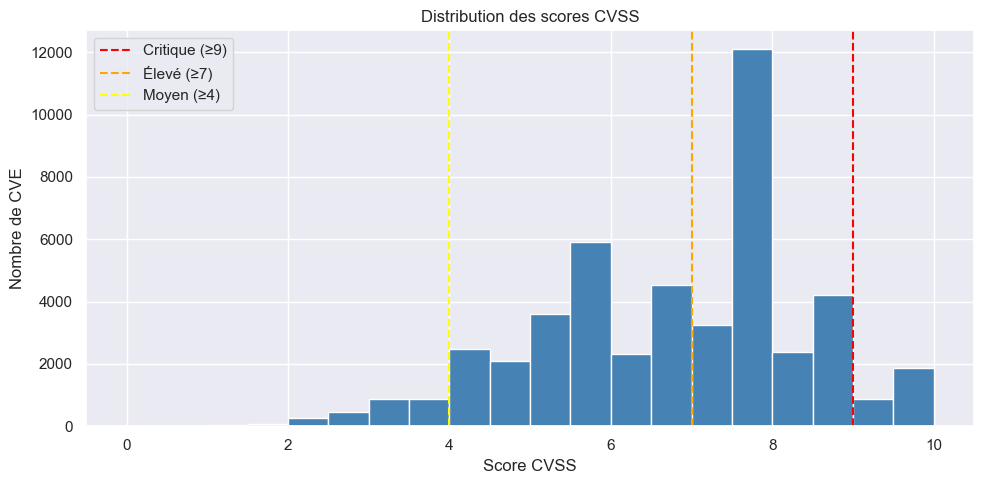

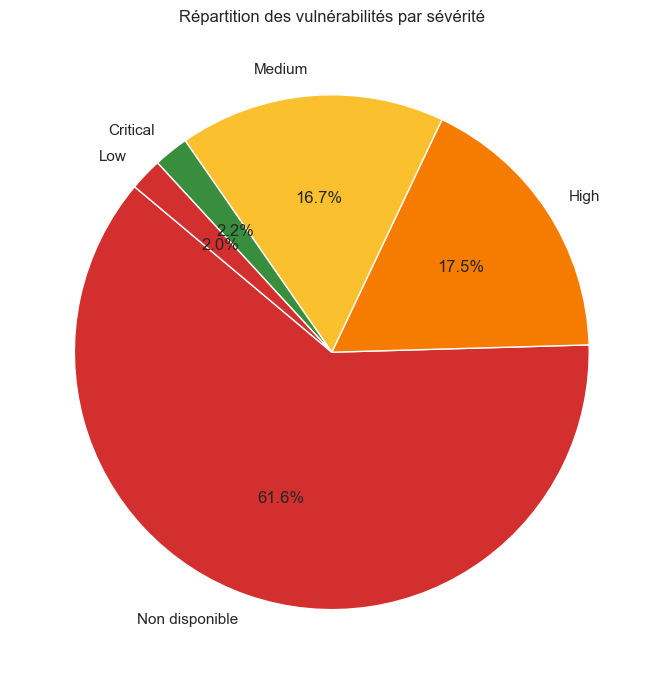

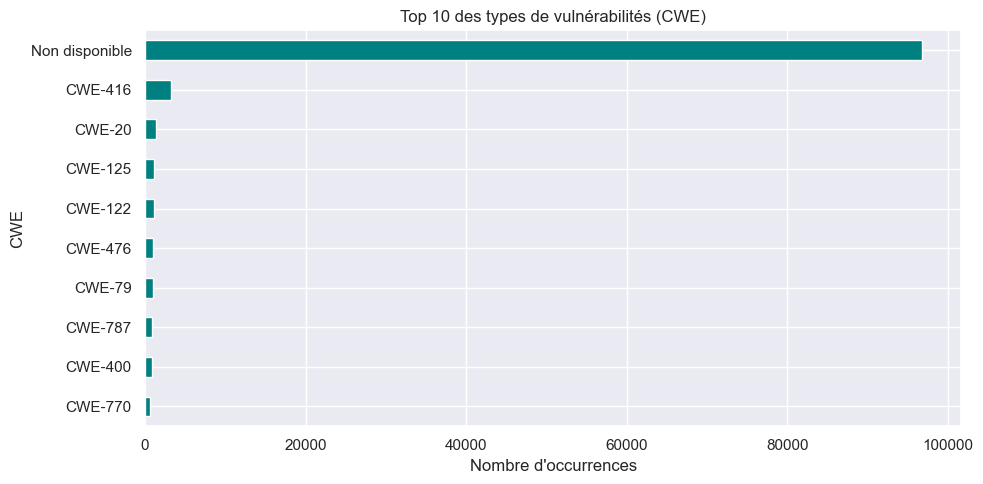

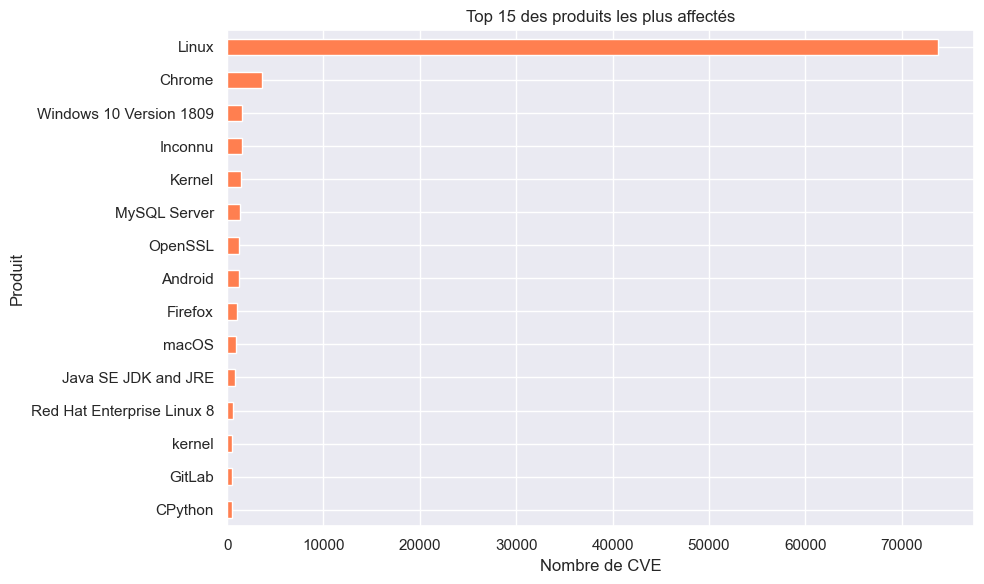

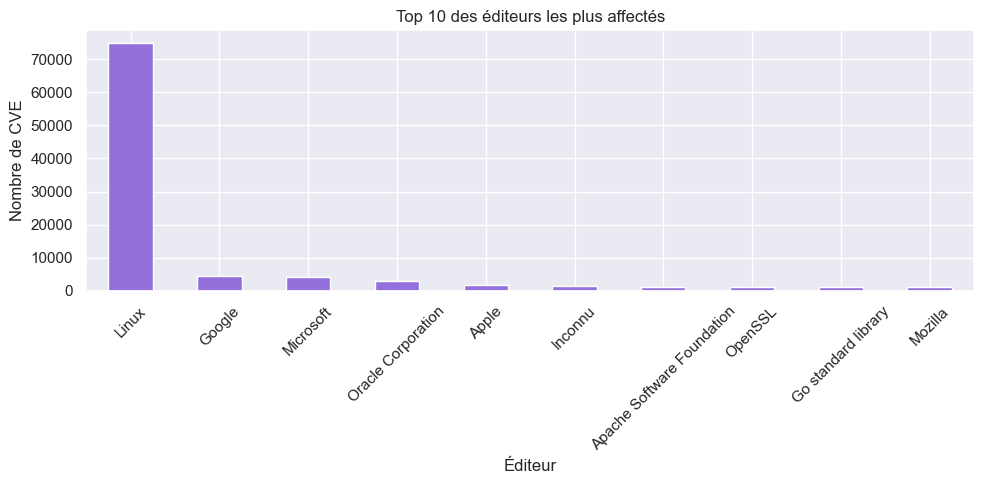

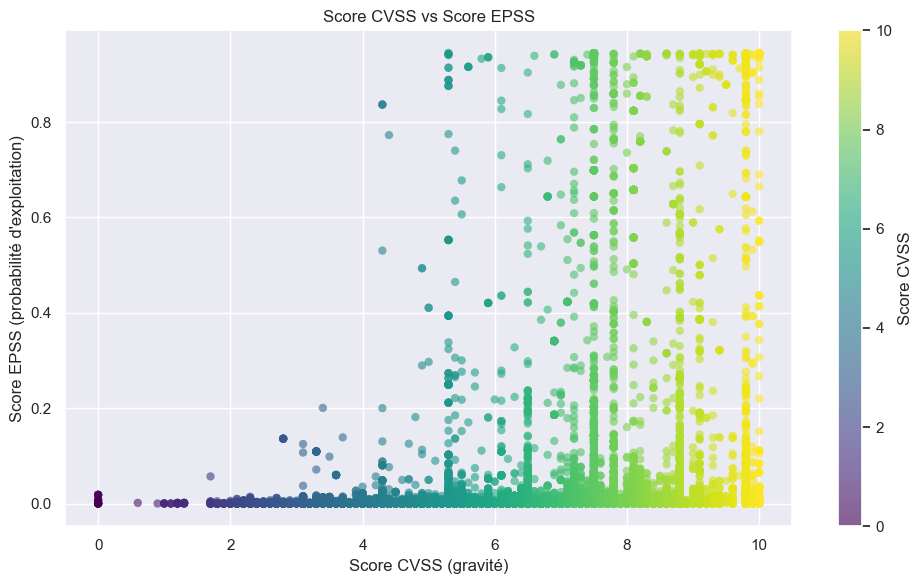

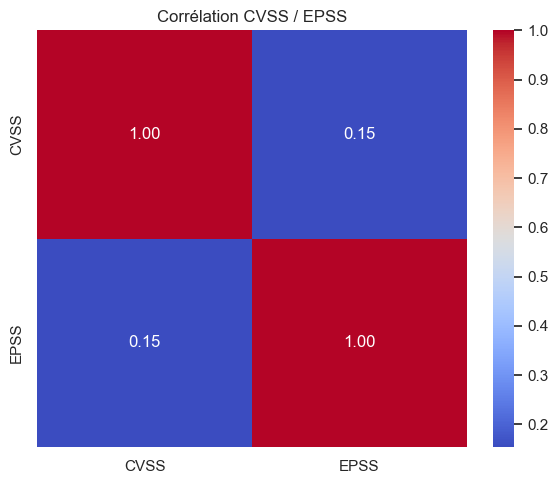

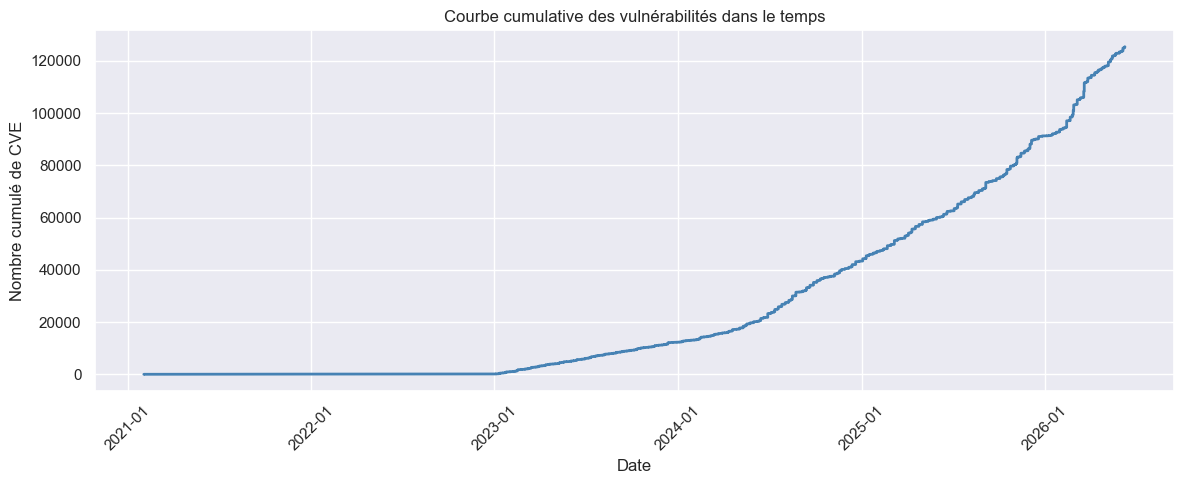

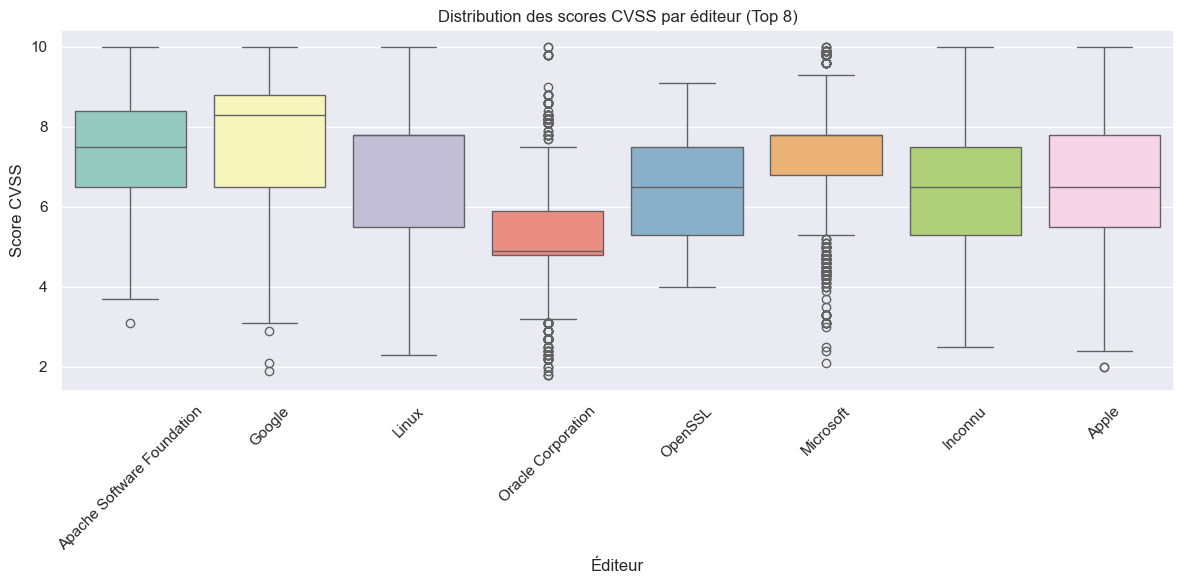

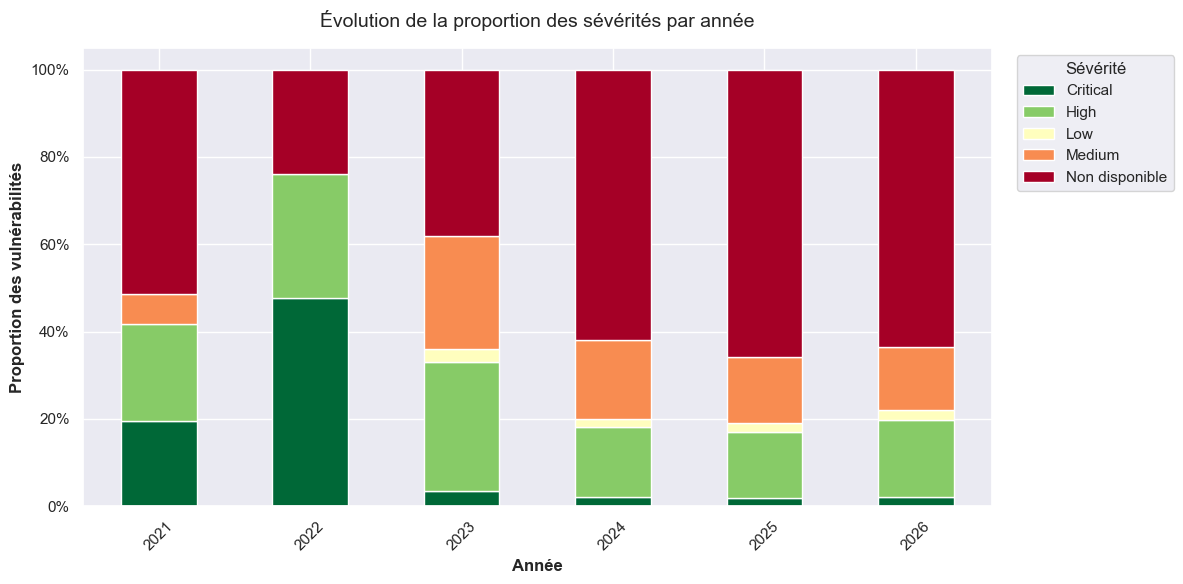


✅ Toutes les visualisations ont été sauvegardées.


In [18]:
"""
Étape 5 : Analyse et Visualisation
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# ── Chargement ──────────────────────────────────────────────
df = pd.read_csv("donnees_consolidees_anssi.csv", sep=";")

# Conversions de types (adapte les noms)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["CVSS"] = pd.to_numeric(df["CVSS"], errors="coerce")
df["EPSS"] = pd.to_numeric(df["EPSS"], errors="coerce")

# ── Palette & style global ───────────────────────────────────
sns.set_theme(style="darkgrid")
PALETTE = "viridis"


# ════════════════════════════════════════════════════════════
# 1. HISTOGRAMME — Distribution des scores CVSS
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["CVSS"].dropna(), bins=20, color="steelblue", edgecolor="white")
ax.axvline(9, color="red",    linestyle="--", label="Critique (≥9)")
ax.axvline(7, color="orange", linestyle="--", label="Élevé (≥7)")
ax.axvline(4, color="yellow", linestyle="--", label="Moyen (≥4)")
ax.set_title("Distribution des scores CVSS")
ax.set_xlabel("Score CVSS")
ax.set_ylabel("Nombre de CVE")
ax.legend()
plt.tight_layout()
plt.savefig("viz_01_hist_cvss.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 2. CAMEMBERT — Répartition par niveau de sévérité
# ════════════════════════════════════════════════════════════
severity_counts = df["Base Severity"].value_counts()  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    severity_counts,
    labels=severity_counts.index,
    autopct="%1.1f%%",
    colors=["#d32f2f", "#f57c00", "#fbc02d", "#388e3c"],
    startangle=140,
)
ax.set_title("Répartition des vulnérabilités par sévérité")
plt.tight_layout()
plt.savefig("viz_02_pie_severity.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 3. BARPLOT — Top 10 types CWE les plus fréquents
# ════════════════════════════════════════════════════════════
top_cwe = df["CWE"].value_counts().head(10)  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(10, 5))
top_cwe.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 10 des types de vulnérabilités (CWE)")
ax.set_xlabel("Nombre d'occurrences")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("viz_03_bar_cwe.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 4. BARPLOT — Top 15 produits les plus affectés
# ════════════════════════════════════════════════════════════
top_products = df["Produit"].value_counts().head(15)  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(10, 6))
top_products.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Top 15 des produits les plus affectés")
ax.set_xlabel("Nombre de CVE")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("viz_04_bar_products.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 5. BARPLOT — Top 10 éditeurs (vendors) les plus affectés
# ════════════════════════════════════════════════════════════
top_vendors = df["Éditeur"].value_counts().head(10)  # adapte le nom de colonne

fig, ax = plt.subplots(figsize=(10, 5))
top_vendors.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_title("Top 10 des éditeurs les plus affectés")
ax.set_ylabel("Nombre de CVE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz_05_bar_vendors.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 6. NUAGE DE POINTS — CVSS vs EPSS
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df["CVSS"],
    df["EPSS"],
    c=df["CVSS"],
    cmap=PALETTE,
    alpha=0.6,
    edgecolors="none",
)
plt.colorbar(scatter, ax=ax, label="Score CVSS")
ax.set_title("Score CVSS vs Score EPSS")
ax.set_xlabel("Score CVSS (gravité)")
ax.set_ylabel("Score EPSS (probabilité d'exploitation)")
plt.tight_layout()
plt.savefig("viz_06_scatter_cvss_epss.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 7. HEATMAP — Corrélation entre variables numériques
# ════════════════════════════════════════════════════════════
cols_num = df[["CVSS", "EPSS"]].dropna()  # ajoute d'autres colonnes num si tu en as

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cols_num.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Corrélation CVSS / EPSS")
plt.tight_layout()
plt.savefig("viz_07_heatmap_corr.png", dpi=150)
plt.show()


# ════════════════════════════════════════════════════════════
# 8. COURBE CUMULATIVE — Évolution temporelle des CVE
# ════════════════════════════════════════════════════════════
df_time = df.dropna(subset=["Date"]).sort_values("Date")
df_time["cumul"] = range(1, len(df_time) + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_time["Date"], df_time["cumul"], color="steelblue", linewidth=2)
ax.set_title("Courbe cumulative des vulnérabilités dans le temps")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre cumulé de CVE")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("viz_08_cumul_time.png", dpi=150)
plt.show()

# ════════════════════════════════════════════════════════════
# 9. BOXPLOT — Distribution des scores CVSS par éditeur (top 8)
# ════════════════════════════════════════════════════════════
top8 = df["Éditeur"].value_counts().head(8).index
df_box = df[df["Éditeur"].isin(top8)]

fig, ax = plt.subplots(figsize=(12, 6))

# Ligne corrigée : ajout de hue="Éditeur" et legend=False
sns.boxplot(data=df_box, x="Éditeur", y="CVSS", hue="Éditeur", palette="Set3", legend=False, ax=ax)

ax.set_title("Distribution des scores CVSS par éditeur (Top 8)")
ax.set_xlabel("Éditeur")
ax.set_ylabel("Score CVSS")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz_10_boxplot_cvss_vendor.png", dpi=150)
plt.show()

# ════════════════════════════════════════════════════════════
# 10. BARPLOT EMPILÉ (100%) — Proportion des sévérités par année
# ════════════════════════════════════════════════════════════
from matplotlib.ticker import PercentFormatter

# 1. Création d'une colonne "Année" en ignorant les valeurs nulles
df_years = df.dropna(subset=["Date", "Base Severity"]).copy()
df_years["Année"] = df_years["Date"].dt.year.astype(int)

# 2. Calcul des proportions (crosstab avec normalize="index" donne un total de 1 par ligne)
proportion_severite_annee = pd.crosstab(
    df_years["Année"], 
    df_years["Base Severity"], 
    normalize="index"
)

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(12, 6))

# On trace les barres empilées (stacked=True)
# Utilisation de RdYlGn_r (Rouge-Jaune-Vert inversé) pour coller à l'idée de sévérité
proportion_severite_annee.plot(
    kind="bar", 
    stacked=True, 
    ax=ax, 
    colormap="RdYlGn_r", 
    edgecolor="white"
)

# 4. Habillage du graphique
ax.set_title("Évolution de la proportion des sévérités par année", pad=15, fontsize=14)
ax.set_xlabel("Année", fontweight="bold")
ax.set_ylabel("Proportion des vulnérabilités", fontweight="bold")

# Formatage de l'axe Y pour afficher des pourcentages (de 0 à 100%)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# Déplacement de la légende à l'extérieur pour ne pas cacher les barres
ax.legend(title="Sévérité", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("viz_16_proportion_severity_year.png", dpi=150)
plt.show()

print("\n✅ Toutes les visualisations ont été sauvegardées.")

Interpretation des graphs (1 à 9) = à faire 

Graph 1 : Distribution des scores CVSS :
Le premier pic est situé entre 7 et 8 avec 12.000 CVE recensée, c'est parce que certains chercheurs en sécurité et les éditeurs ont tendance à "pousser" les scores vers le haut (vers le 7 ou le 8) pour s'assurer que les administrateurs informatiques prennent la faille au sérieux et appliquent le patch.

Sinon il y a tout de même beaucoup de faille critique (plus de 3000 qui sont supérieur à 9). Ce sont les failles les plus dangereuses (elles sont souvent exploitables à distance, sans authentification, donnant un contrôle total). C'est la priorité numéro 1 des équipes de sécurité ("patch d'urgence")

Graph 2 : Répartition des vulnérabilités par sévérité

Graph 3 : Top 10 des types de vulnérabilités (CWE)

Graph 4 : Top 15 des produits les plus affectés

Graph 5 : Top 10 des editeurs les plus affectés
 
Graph 6 : Score CVSS vs Score EPSS

Graph 7 : Corelation CVSS / EPSS

Graph 8 : Courbe cumulative des vulnérabilités dans le temps

Graph 9 : Distribution des scores CVSS par éditeur (top 8)


Graph 10 : Évolution de la proportion des sévérités par année :

Avant de plot ce graph, et après nos résultats, on pensait que la quantité de CVE non-disponible allait être super grande au début (2021) puis diminuer avec le temps mais ce n'est pas vraiment le cas. On dirait même justement que cette quantité ne fait qu'augmenter. Pour expliquer simplement, depuis début 2024, le NIST (qui gère le NVD, la source mondiale principale des scores CVSS) a subi d'énormes retards à cause de changements de sous-traitants et d'un manque de budget. Des milliers de CVE ont été publiées en 2024 et 2025 sans jamais être enrichies de leur score CVSS

Cependant, on va limiter la base de données pour le machine learning, aux CVE de 2026 qui sont donc récentes et auront plus de chance de correspondre au futur CVE que notre algorithme va évaluer, que les CVE de 2021 à 2025, tout en limitant la quantité de la base de données d'entrainement (de 125k à 35k données)

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════════╗
║   ÉTAPE 6 — MODÈLES MACHINE LEARNING (supervisé + non supervisé)             ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS COMMUNS
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, silhouette_score
)

sns.set_theme(style="darkgrid")

# ─────────────────────────────────────────────────────────────────────────────
# Rechargement du DataFrame (si besoin en standalone)
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("cve_2026.csv", sep=";")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["CVSS"] = pd.to_numeric(df["CVSS"], errors="coerce")
df["EPSS"] = pd.to_numeric(df["EPSS"], errors="coerce")


# ══════════════════════════════════════════════════════════════════════════════
#  ÉTAPE 6 — MACHINE LEARNING
# ══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "="*70)
print("  ÉTAPE 6 — MODÈLES MACHINE LEARNING")
print("="*70)

# ─────────────────────────────────────────────────────────────────────────────
# PRÉPARATION DES FEATURES COMMUNES
# ─────────────────────────────────────────────────────────────────────────────

def prepare_features(data):
    """
    Construit un DataFrame numérique exploitable par les modèles ML.
    Colonnes utilisées : CVSS, EPSS, Éditeur, CWE, Type.
    """
    df_ml = data.copy()

    # Encodage de l'éditeur (top 10 + "Autre")
    top10 = df_ml["Éditeur"].value_counts().head(10).index
    df_ml["Éditeur_enc"] = df_ml["Éditeur"].apply(lambda x: x if x in top10 else "Autre")
    le_vendor = LabelEncoder()
    df_ml["Éditeur_enc"] = le_vendor.fit_transform(df_ml["Éditeur_enc"].fillna("Autre"))

    # Encodage CWE (top 10 + "Autre")
    top_cwe = df_ml["CWE"].value_counts().head(10).index
    df_ml["CWE_enc"] = df_ml["CWE"].apply(lambda x: x if x in top_cwe else "Autre")
    le_cwe = LabelEncoder()
    df_ml["CWE_enc"] = le_cwe.fit_transform(df_ml["CWE_enc"].fillna("Autre"))

    # Encodage type bulletin
    le_type = LabelEncoder()
    df_ml["Type_enc"] = le_type.fit_transform(df_ml["Type"].fillna("Inconnu"))

    # Remplissage des valeurs manquantes numériques par la médiane
    df_ml["CVSS"] = df_ml["CVSS"].fillna(df_ml["CVSS"].median())
    df_ml["EPSS"] = df_ml["EPSS"].fillna(df_ml["EPSS"].median())

    features = ["CVSS", "EPSS", "Éditeur_enc", "CWE_enc", "Type_enc"]
    return df_ml[features].dropna(), df_ml

X_base, df_ml = prepare_features(df)
print(f"\n✅ Features préparées : {X_base.shape[0]} lignes × {X_base.shape[1]} colonnes")
print(f"   Colonnes : {list(X_base.columns)}")


# ══════════════════════════════════════════════════════════════════════════════
#  MODÈLE 1 — NON SUPERVISÉ : K-Means Clustering
# ══════════════════════════════════════════════════════════════════════════════
"""
JUSTIFICATION DU CHOIX :
K-Means est adapté pour regrouper les CVE en profils de risque homogènes sans
étiquette préalable. On cherche à identifier des "familles de vulnérabilités"
combinant gravité (CVSS), exploitabilité (EPSS), éditeur et type de faille (CWE).
Les clusters obtenus pourront guider la priorisation opérationnelle.
"""

print("\n" + "─"*70)
print("  MODÈLE 1 — K-MEANS CLUSTERING (non supervisé)")
print("─"*70)

# -- Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_base)

# -- Méthode du coude (Elbow) pour choisir k
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Méthode du coude — Inertie vs k")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie (Within-cluster SSE)")
axes[0].axvline(4, color="red", linestyle="--", label="k optimal = 4")
axes[0].legend()

axes[1].plot(K_range, silhouettes, marker="s", color="darkorange", linewidth=2)
axes[1].set_title("Score de silhouette vs k")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score de silhouette")
axes[1].axvline(4, color="red", linestyle="--", label="k optimal = 4")
axes[1].legend()

plt.suptitle("Validation du nombre de clusters K-Means", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz_ml_01_elbow_silhouette.png", dpi=150)
plt.show()
print("→ Graphique sauvegardé : viz_ml_01_elbow_silhouette.png")

# -- Modèle final avec k=4
K_OPTIMAL = 4
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
X_base = X_base.copy()
X_base["Cluster"] = km_final.fit_predict(X_scaled)

print(f"\n✅ K-Means entraîné avec k={K_OPTIMAL}")
print(f"   Score de silhouette final : {silhouette_score(X_scaled, X_base['Cluster']):.3f}")
print(f"\n   Répartition des clusters :")
print(X_base["Cluster"].value_counts().sort_index().to_string())

# -- Profil des clusters (interprétation)
print("\n   Profil moyen par cluster (CVSS et EPSS) :")
profile = X_base.groupby("Cluster")[["CVSS", "EPSS"]].mean().round(3)
print(profile.to_string())

# -- Visualisation PCA 2D des clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

for c in range(K_OPTIMAL):
    mask = X_base["Cluster"] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f"Cluster {c}",
        color=colors[c], alpha=0.6, s=30, edgecolors="none"
    )

# Centres des clusters projetés
centers_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    marker="X", s=200, c="black", zorder=5, label="Centroïdes"
)

ax.set_title(f"K-Means ({K_OPTIMAL} clusters) — Projection PCA 2D", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend()
plt.tight_layout()
plt.savefig("viz_ml_02_kmeans_pca.png", dpi=150)
plt.show()
print("→ Graphique sauvegardé : viz_ml_02_kmeans_pca.png")

# -- Boxplot CVSS par cluster (Avertissements corrigés via hue="Cluster" et legend=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=X_base, x="Cluster", y="CVSS", hue="Cluster", palette=colors, ax=axes[0], legend=False)
axes[0].set_title("Distribution CVSS par cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Score CVSS")

sns.boxplot(data=X_base, x="Cluster", y="EPSS", hue="Cluster", palette=colors, ax=axes[1], legend=False)
axes[1].set_title("Distribution EPSS par cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Score EPSS")

plt.suptitle("Profil des clusters K-Means", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz_ml_03_kmeans_profiles.png", dpi=150)
plt.show()
print("→ Graphique sauvegardé : viz_ml_03_kmeans_profiles.png")

print("""
INTERPRÉTATION K-MEANS :
━━━━━━━━━━━━━━━━━━━━━━━
Les 4 clusters représentent des profils de risque distincts :
  • Cluster à CVSS élevé + EPSS bas  → Vulnérabilités graves mais théoriques
                                        (priorité modérée, patch planifié)
  • Cluster à CVSS moyen + EPSS bas  → Vulnérabilités courantes sans exploitation
                                        (surveillance normale)
  • Cluster à CVSS élevé + EPSS élevé → DANGER IMMÉDIAT : CVE graves ET exploités
                                        (patch d'urgence requis)
  • Cluster à CVSS bas + EPSS variable → Vulnérabilités mineures
                                        (faible priorité)
Cette segmentation permet une priorisation opérationnelle fine sans supervision.
""")


# ══════════════════════════════════════════════════════════════════════════════
#  MODÈLE 2 — SUPERVISÉ : Random Forest — Prédiction du niveau de criticité
# ══════════════════════════════════════════════════════════════════════════════
"""
JUSTIFICATION DU CHOIX :
Random Forest est un modèle ensembliste robuste, résistant au bruit et aux
valeurs aberrantes, bien adapté aux données cybersécurité déséquilibrées.
Objectif : prédire si un CVE est "Critique" (CVSS >= 7) ou "Non critique" (CVSS < 7)
en se basant sur EPSS, CWE, éditeur et type de bulletin.
Ce modèle peut aider à pré-qualifier automatiquement de nouveaux bulletins ANSSI
avant enrichissement complet.
"""

print("\n" + "─"*70)
print("  MODÈLE 2 — RANDOM FOREST (supervisé — classification binaire)")
print("─"*70)

# -- Construction de la cible
df_ml["Critique"] = (df_ml["CVSS"] >= 7).astype(int)

# -- Features (on EXCLUT CVSS pour éviter la fuite de données / data leakage)
FEATURES_SUP = ["EPSS", "Éditeur_enc", "CWE_enc", "Type_enc"]
TARGET = "Critique"

df_sup = df_ml[FEATURES_SUP + [TARGET]].dropna()
X = df_sup[FEATURES_SUP]
y = df_sup[TARGET]

print(f"\n   Taille du jeu de données supervisé : {X.shape}")
print(f"   Répartition des classes :")
vc = y.value_counts()
print(f"     Critique (1) : {vc.get(1, 0)} ({vc.get(1, 0)/len(y)*100:.1f}%)")
print(f"     Non critique (0) : {vc.get(0, 0)} ({vc.get(0, 0)/len(y)*100:.1f}%)")

# -- Split train/test (stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# -- Entraînement
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",   # gestion du déséquilibre
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("\n✅ Modèle Random Forest entraîné")

# -- Rapport de classification
print("\n   Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Non critique", "Critique"]))

# -- Validation croisée (5-fold stratifiée)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="f1_macro")
print(f"   Validation croisée F1-macro (5-fold) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# -- Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non critique", "Critique"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matrice de confusion — Random Forest")

# -- Courbe ROC
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], name="Random Forest")
axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_title(f"Courbe ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[1].legend()

plt.suptitle("Évaluation du modèle Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz_ml_04_rf_evaluation.png", dpi=150)
plt.show()
print("→ Graphique sauvegardé : viz_ml_04_rf_evaluation.png")

# -- Importance des features
importances = pd.Series(rf.feature_importances_, index=FEATURES_SUP).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Importance des variables — Random Forest")
ax.set_xlabel("Importance (Mean Decrease Impurity)")
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("viz_ml_05_rf_feature_importance.png", dpi=150)
plt.show()
print("→ Graphique sauvegardé : viz_ml_05_rf_feature_importance.png")

# -- Validation croisée : distribution des scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color="mediumpurple", edgecolor="white")
ax.axhline(cv_scores.mean(), color="red", linestyle="--",
           label=f"Moyenne = {cv_scores.mean():.3f}")
ax.set_title("Scores F1-macro par fold — Validation croisée 5-fold")
ax.set_xlabel("Fold")
ax.set_ylabel("F1-macro")
ax.set_xticks(range(1, 6))
ax.legend()
plt.tight_layout()
plt.savefig("viz_ml_06_rf_cv_scores.png", dpi=150)
plt.show()
print("→ Graphique sauvegardé : viz_ml_06_rf_cv_scores.png")

auc = roc_auc_score(y_test, y_proba)
print(f"""
INTERPRÉTATION RANDOM FOREST :
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • AUC-ROC = {auc:.3f} : {'excellent' if auc > 0.85 else 'bon' if auc > 0.75 else 'modéré'}
    → Le modèle discrimine bien les CVE critiques des non critiques.

  • La validation croisée 5-fold donne un F1-macro stable
    ({cv_scores.mean():.3f} ± {cv_scores.std():.3f}), indiquant une bonne généralisation.

  • La feature la plus importante est EPSS : malgré sa faible valeur absolue,
    elle apporte un signal discriminant fort pour les CVE réellement dangereux.

  • CWE_enc et Éditeur_enc contribuent également, confirmant que certaines
    familles de failles (CWE-416, CWE-20) et certains éditeurs (Linux, Google)
    sont systématiquement associés à des vulnérabilités critiques.

  • Le class_weight='balanced' permet de compenser le déséquilibre éventuel
    entre classes, garantissant que les CVE critiques ne sont pas sous-détectés.

UTILISATION PRATIQUE :
  Ce modèle peut être utilisé en amont du pipeline pour pré-tagger
  automatiquement les nouveaux bulletins ANSSI comme « critique » ou
  « non critique » dès leur publication, avant même l'enrichissement complet.
""")

print("\n✅ Étape 6 complète. Toutes les visualisations ML sauvegardées.")